# Lab 4_2

**I. Object Localization**

- Download the VOC dataset

In [10]:
import os, tarfile, urllib.request

def download_voc2007(dest="data"):
    url = "http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar"
    tar_path = os.path.join(dest, "VOCtrainval.tar")
    os.makedirs(dest, exist_ok=True)

    if not os.path.exists(tar_path):
        print("Downloading VOC 2007 (~870 MB)...")
        urllib.request.urlretrieve(url, tar_path,
            reporthook=lambda b,bs,ts: print(
                f"\r  {min(b*bs,ts)/1e6:.0f} / {ts/1e6:.0f} MB", end=""))
        print()

    print("Extracting...")
    with tarfile.open(tar_path) as t:
        t.extractall(dest)
    print(f"Done → {dest}/VOCdevkit/VOC2007/")

In [11]:
download_voc2007()

Extracting...
Done → data/VOCdevkit/VOC2007/


In [12]:

import os, time, xml.etree.ElementTree as ET
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from PIL import Image

# ── Constants ────────────────────────────────────────────────────────────────
VOC_CLASSES = [
    "__background__","aeroplane","bicycle","bird","boat","bottle","bus","car",
    "cat","chair","cow","diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]
CLASS_TO_IDX  = {c: i for i, c in enumerate(VOC_CLASSES)}
NUM_CLASSES   = len(VOC_CLASSES)   # 21
IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LR            = 1e-3
LAMBDA_REG    = 1.0                # weight for box regression loss
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:

# ── Dataset ──────────────────────────────────────────────────────────────────
# For single-object localization we keep only the LARGEST box per image
# (by area). This is a common simplification on VOC for localization tasks
# (Russakovsky et al., IJCV 2015 §3.4).

class VOCLocalizationDataset(Dataset):
    """
    Returns (image_tensor, label, box_normalized) where
    box_normalized = [cx, cy, w, h] in [0,1] relative to IMG_SIZE.
    """
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, root="data/VOCdevkit/VOC2007", split="train"):
        self.img_dir = os.path.join(root, "JPEGImages")
        self.ann_dir = os.path.join(root, "Annotations")
        split_file   = os.path.join(root, "ImageSets", "Main", f"{split}.txt")
        with open(split_file) as f:
            self.ids = [l.strip() for l in f if l.strip()]

        self.tf = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD),
        ])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, f"{img_id}.jpg")).convert("RGB")
        W, H   = img.size                      # original size before resize

        tree = ET.parse(os.path.join(self.ann_dir, f"{img_id}.xml"))
        root = tree.getroot()

        best_box, best_label, best_area = None, 0, -1
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name not in CLASS_TO_IDX:
                continue
            if int(obj.find("difficult").text):
                continue
            bb   = obj.find("bndbox")
            x1   = float(bb.find("xmin").text)
            y1   = float(bb.find("ymin").text)
            x2   = float(bb.find("xmax").text)
            y2   = float(bb.find("ymax").text)
            area = (x2 - x1) * (y2 - y1)
            if area > best_area:
                best_area  = area
                best_box   = [x1, y1, x2, y2]
                best_label = CLASS_TO_IDX[name]

        if best_box is None:          # no valid object → zero box, background
            best_box, best_label = [0., 0., 1., 1.], 0

        # Normalise to [0,1] then convert to cx,cy,w,h
        x1, y1, x2, y2 = best_box
        x1 /= W; x2 /= W; y1 /= H; y2 /= H
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        bw = x2 - x1
        bh = y2 - y1
        box = torch.tensor([cx, cy, bw, bh], dtype=torch.float32)

        return self.tf(img), torch.tensor(best_label, dtype=torch.long), box

In [14]:

class LocalizationNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        backbone         = models.resnet50(weights="IMAGENET1K_V1" if pretrained else None)
        self.features    = nn.Sequential(*list(backbone.children())[:-1])  # → (B,2048,1,1)
        feat_dim         = 2048

        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.reg_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 4),
            nn.Sigmoid()               # output in (0,1)
        )

    def forward(self, x):
        f = self.features(x)
        return self.cls_head(f), self.reg_head(f)


# ── Metric helpers ────────────────────────────────────────────────────────────
def cxcywh_to_xyxy(box):
    """box: (..., 4) in cx,cy,w,h → x1,y1,x2,y2"""
    cx, cy, w, h = box[...,0], box[...,1], box[...,2], box[...,3]
    return torch.stack([cx-w/2, cy-h/2, cx+w/2, cy+h/2], dim=-1)


def batch_iou(pred_box, gt_box):
    """
    Vectorised IoU for matched pairs.
    pred_box, gt_box: (B,4) in cx,cy,w,h
    Returns IoU tensor of shape (B,)
    """
    p = cxcywh_to_xyxy(pred_box)
    g = cxcywh_to_xyxy(gt_box)

    ix1 = torch.max(p[:,0], g[:,0])
    iy1 = torch.max(p[:,1], g[:,1])
    ix2 = torch.min(p[:,2], g[:,2])
    iy2 = torch.min(p[:,3], g[:,3])

    inter = (ix2-ix1).clamp(0) * (iy2-iy1).clamp(0)
    area_p = (p[:,2]-p[:,0]) * (p[:,3]-p[:,1])
    area_g = (g[:,2]-g[:,0]) * (g[:,3]-g[:,1])
    union  = area_p + area_g - inter
    return inter / union.clamp(min=1e-6)

In [15]:

# ── Train / Eval loops ───────────────────────────────────────────────────────

def run_epoch(model, loader, optimizer, criterion_cls, criterion_reg, train=True):
    model.train() if train else model.eval()
    total_loss = total_cls = total_reg = 0.0
    n_correct  = 0
    iou_list   = []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels, boxes in loader:
            imgs, labels, boxes = imgs.to(DEVICE), labels.to(DEVICE), boxes.to(DEVICE)

            logits, pred_box = model(imgs)

            loss_cls = criterion_cls(logits, labels)
            loss_reg = criterion_reg(pred_box, boxes)
            loss     = loss_cls + LAMBDA_REG * loss_reg

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_cls  += loss_cls.item()
            total_reg  += loss_reg.item()
            n_correct  += (logits.argmax(1) == labels).sum().item()
            iou_list.append(batch_iou(pred_box.detach(), boxes).cpu())

    N = len(loader.dataset)
    iou_all = torch.cat(iou_list)
    return {
        "loss":     total_loss / len(loader),
        "loss_cls": total_cls  / len(loader),
        "loss_reg": total_reg  / len(loader),
        "acc":      n_correct  / N,
        "mean_iou": iou_all.mean().item(),
        # CorLoc: fraction of images with IoU ≥ 0.5
        # Standard metric for single-object localization (Deselaers et al. 2012)
        "corloc":   (iou_all >= 0.5).float().mean().item(),
    }


def print_metrics(epoch, num_epochs, tr, va, elapsed):
    print(f"\nEpoch {epoch}/{num_epochs}  ({elapsed:.1f}s)")
    print(f"  {'':10} {'loss':>7} {'cls':>7} {'reg':>7} {'acc':>7} {'mIoU':>7} {'CorLoc':>7}")
    print(f"  {'train':10} {tr['loss']:7.4f} {tr['loss_cls']:7.4f} {tr['loss_reg']:7.4f}"
          f" {tr['acc']:7.4f} {tr['mean_iou']:7.4f} {tr['corloc']:7.4f}")
    print(f"  {'val':10} {va['loss']:7.4f} {va['loss_cls']:7.4f} {va['loss_reg']:7.4f}"
          f" {va['acc']:7.4f} {va['mean_iou']:7.4f} {va['corloc']:7.4f}")

In [16]:

def train():
    print(f"Device: {DEVICE}")

    train_ds = VOCLocalizationDataset(split="train")
    val_ds   = VOCLocalizationDataset(split="val")

    # Use subsets if you want faster iteration:
    # train_ds = Subset(train_ds, range(800))
    # val_ds   = Subset(val_ds,   range(200))

    # train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
    #                           num_workers=4, pin_memory=True)
    # val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
    #                           num_workers=4, pin_memory=True)
        # Jupyter + Windows: multiprocessing workers often crash (pickle/spawn).
    # Use 0 workers here; on Linux CLI you can try num_workers=4.
    _pin = DEVICE.type == "cuda"
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, pin_memory=_pin,
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=0, pin_memory=_pin,
    )

    model        = LocalizationNet().to(DEVICE)

    # Phase 1: freeze backbone, only train heads
    for param in model.features.parameters():
        param.requires_grad = False

    optimizer    = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=1e-4
    )
    scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    UNFREEZE_EPOCH = 15   # unfreeze backbone after this epoch
    criterion_cls = nn.CrossEntropyLoss()
    criterion_reg = nn.SmoothL1Loss()          # Huber loss, δ=1 by default

    best_corloc = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr = run_epoch(model, train_loader, optimizer, criterion_cls, criterion_reg, train=True)
        va = run_epoch(model, val_loader,   optimizer, criterion_cls, criterion_reg, train=False)
        scheduler.step()

        print_metrics(epoch, NUM_EPOCHS, tr, va, time.time() - t0)

        # Phase 2: unfreeze backbone with lower LR
        if epoch == UNFREEZE_EPOCH:
            print("  *** Unfreezing backbone (differential LR) ***")
            for param in model.features.parameters():
                param.requires_grad = True
            optimizer = torch.optim.AdamW([
                {"params": model.features.parameters(),  "lr": 1e-4},
                {"params": model.cls_head.parameters(),  "lr": 1e-3},
                {"params": model.reg_head.parameters(),  "lr": 1e-3},
            ], weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - UNFREEZE_EPOCH
            )

        if va["corloc"] > best_corloc:
            best_corloc = va["corloc"]
            torch.save(model.state_dict(), "localization_best.pth")
            print(f"  *** best saved  CorLoc={best_corloc:.4f} ***")

    torch.save(model.state_dict(), "localization_final.pth")
    print(f"\nDone. Best val CorLoc: {best_corloc:.4f}")

In [17]:
train()

Device: cpu

Epoch 1/50  (494.5s)
                loss     cls     reg     acc    mIoU  CorLoc
  train       1.5671  1.5492  0.0179  0.5670  0.3765  0.3239
  val         0.8593  0.8457  0.0136  0.7522  0.4006  0.3880
  *** best saved  CorLoc=0.3880 ***

Epoch 2/50  (422.5s)
                loss     cls     reg     acc    mIoU  CorLoc
  train       0.8652  0.8513  0.0139  0.7313  0.4074  0.3842
  val         0.7395  0.7264  0.0131  0.7749  0.3994  0.3865

Epoch 3/50  (420.7s)
                loss     cls     reg     acc    mIoU  CorLoc
  train       0.7156  0.7028  0.0128  0.7773  0.4155  0.4122
  val         0.6735  0.6612  0.0123  0.7920  0.4321  0.4458
  *** best saved  CorLoc=0.4458 ***

Epoch 4/50  (422.5s)
                loss     cls     reg     acc    mIoU  CorLoc
  train       0.6349  0.6224  0.0125  0.8041  0.4224  0.4234
  val         0.6800  0.6679  0.0120  0.7845  0.4357  0.4494
  *** best saved  CorLoc=0.4494 ***

Epoch 5/50  (423.5s)
                loss     cls     reg  

Loading checkpoint: localization_best.pth


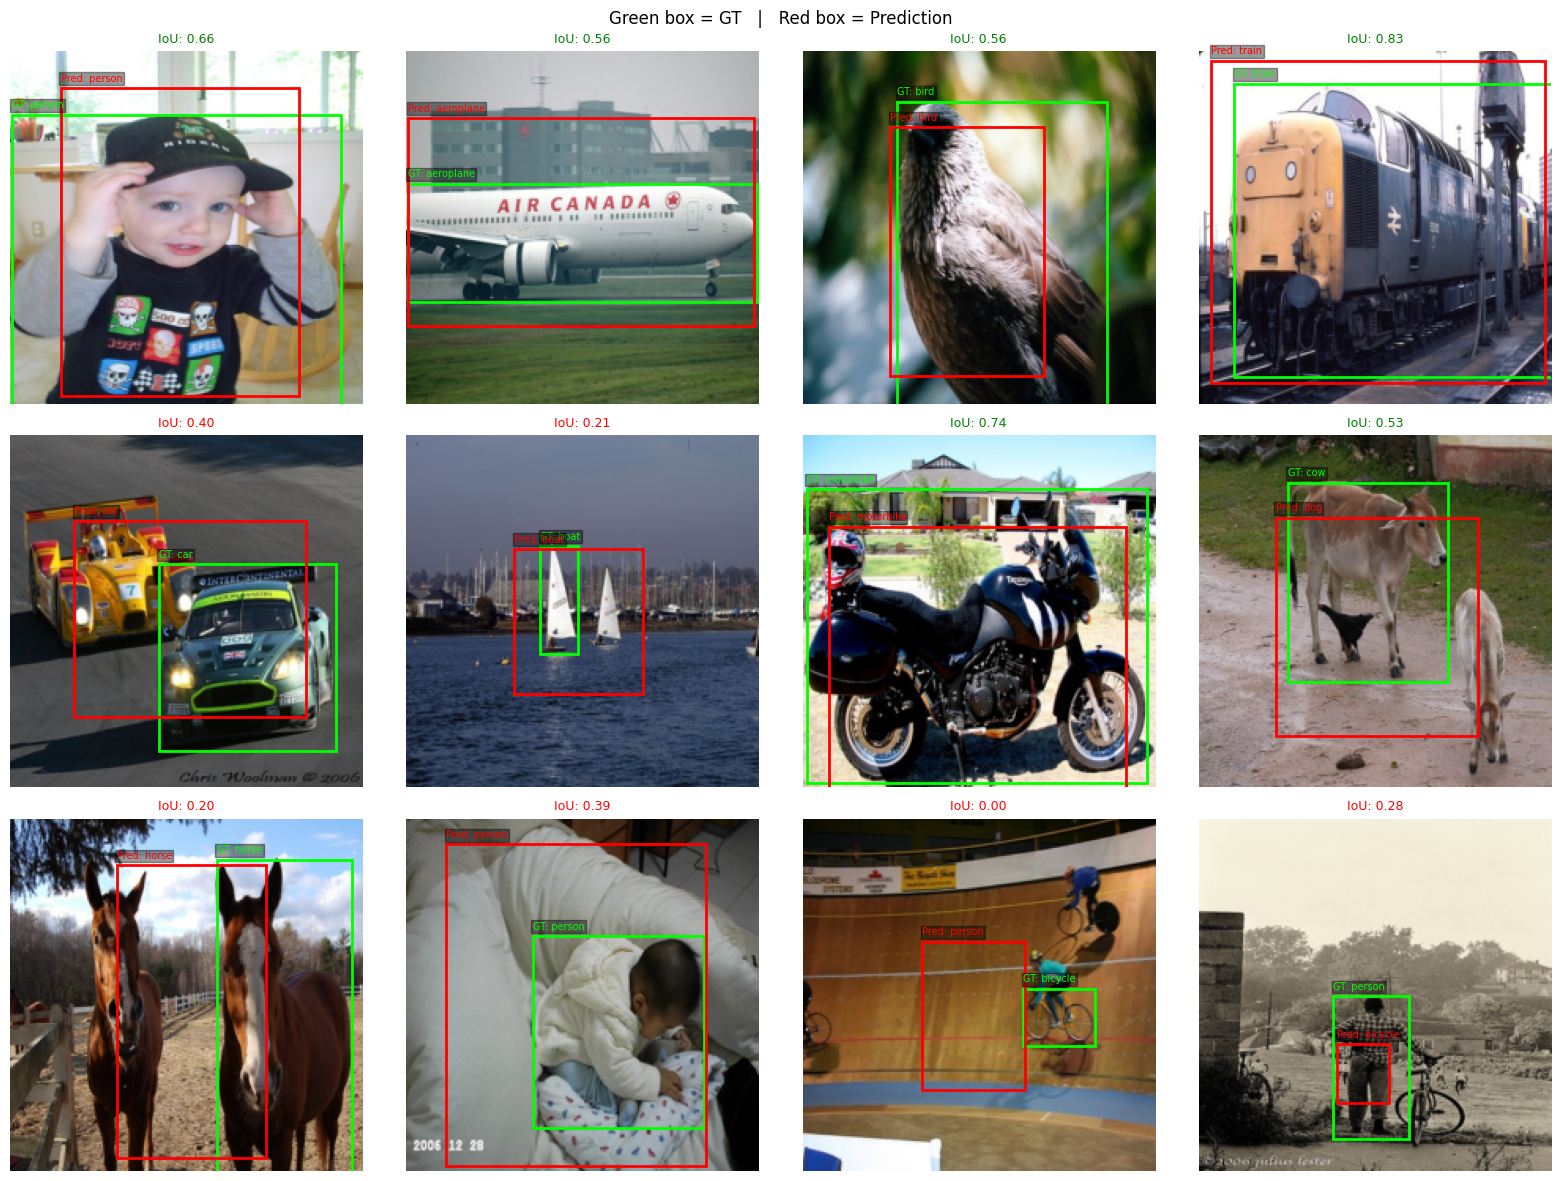

In [20]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def denormalize(img_tensor):
    img = img_tensor.clone().cpu()
    for c, m, s in zip(img, MEAN, STD):
        c.mul_(s).add_(m)
    return img.permute(1, 2, 0).clamp(0, 1).numpy()

def iou(b1, b2):
    def to_xyxy(b):
        cx,cy,w,h = b
        return cx-w/2, cy-h/2, cx+w/2, cy+h/2
    ax1,ay1,ax2,ay2 = to_xyxy(b1)
    bx1,by1,bx2,by2 = to_xyxy(b2)
    ix = max(0, min(ax2,bx2) - max(ax1,bx1))
    iy = max(0, min(ay2,by2) - max(ay1,by1))
    inter = ix * iy
    union = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter / max(union, 1e-6)

def draw_box(ax, box, H, W, color, label):
    cx,cy,bw,bh = box
    x1 = (cx - bw/2) * W
    y1 = (cy - bh/2) * H
    ax.add_patch(patches.Rectangle(
        (x1, y1), bw*W, bh*H,
        linewidth=2, edgecolor=color, facecolor="none"
    ))
    ax.text(x1, y1-4, label, color=color, fontsize=7,
            bbox=dict(facecolor="black", alpha=0.4, pad=1))

# ── Load model ────────────────────────────────────────────────────────────────
# Pick the first checkpoint that actually exists (works on Kaggle and locally).
_candidates = [
    "localization_best.pth",
    "localization_final.pth",
    "/kaggle/working/localization_best.pth",
    "/kaggle/working/localization_final.pth",
]
ckpt = next((p for p in _candidates if os.path.exists(p)), None)
if ckpt is None:
    raise FileNotFoundError(
        "No localization checkpoint found. Run the training cell first."
    )
print(f"Loading checkpoint: {ckpt}")

model = LocalizationNet().to(DEVICE)
model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
model.eval()

val_ds = VOCLocalizationDataset(split="val")
indices = np.random.choice(len(val_ds), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, indices):
        img_t, label, gt_box = val_ds[idx]
        logits, pred_box = model(img_t.unsqueeze(0).to(DEVICE))

        pred_cls = logits.argmax(1).item()
        pred_box = pred_box[0].cpu().numpy()
        gt_box   = gt_box.numpy()

        img_np   = denormalize(img_t)
        H, W     = img_np.shape[:2]
        score    = iou(gt_box, pred_box)

        ax.imshow(img_np)
        draw_box(ax, gt_box,   H, W, "lime", "GT: " + VOC_CLASSES[label])
        draw_box(ax, pred_box, H, W, "red",  "Pred: " + VOC_CLASSES[pred_cls])
        ax.set_title(f"IoU: {score:.2f}", fontsize=9,
                     color="green" if score >= 0.5 else "red")
        ax.axis("off")

plt.suptitle("Green box = GT   |   Red box = Prediction", fontsize=12)
plt.tight_layout()
# Save next to the checkpoint so it works on Kaggle and locally.
_out_dir = os.path.dirname(os.path.abspath(ckpt))
plt.savefig(os.path.join(_out_dir, "predictions.png"),
            dpi=150, bbox_inches="tight")
plt.show()

**II. Bài toán Object Dection**

- Download the VOC dataset

In [1]:
import os, tarfile, urllib.request

def download_voc2007(dest="data"):
    url = "http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar"
    tar_path = os.path.join(dest, "VOCtrainval.tar")
    os.makedirs(dest, exist_ok=True)

    if not os.path.exists(tar_path):
        print("Downloading VOC 2007 (~870 MB)...")
        urllib.request.urlretrieve(url, tar_path,
            reporthook=lambda b,bs,ts: print(
                f"\r  {min(b*bs,ts)/1e6:.0f} / {ts/1e6:.0f} MB", end=""))
        print()

    print("Extracting...")
    with tarfile.open(tar_path) as t:
        t.extractall(dest)
    print(f"Done → {dest}/VOCdevkit/VOC2007/")


In [2]:
download_voc2007()

Extracting...
Done → data/VOCdevkit/VOC2007/


In [3]:
import os, xml.etree.ElementTree as ET
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as F

VOC_CLASSES = [
    "__background__",
    "aeroplane","bicycle","bird","boat","bottle","bus","car","cat",
    "chair","cow","diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]
CLASS_TO_IDX = {c: i for i, c in enumerate(VOC_CLASSES)}


class VOCDataset(Dataset):
    def __init__(self, root="data/VOCdevkit/VOC2007", split="train", transforms=None):
        self.root       = root
        self.transforms = transforms
        self.img_dir    = os.path.join(root, "JPEGImages")
        self.ann_dir    = os.path.join(root, "Annotations")

        split_file = os.path.join(root, "ImageSets", "Main", f"{split}.txt")
        with open(split_file) as f:
            self.ids = [l.strip() for l in f if l.strip()]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        # Load image
        img = Image.open(os.path.join(self.img_dir, f"{img_id}.jpg")).convert("RGB")
        img_tensor = F.to_tensor(img)

        # Parse XML annotation
        tree = ET.parse(os.path.join(self.ann_dir, f"{img_id}.xml"))
        root = tree.getroot()

        boxes, labels = [], []
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name not in CLASS_TO_IDX:
                continue
            difficult = int(obj.find("difficult").text)
            if difficult:
                continue
            bb = obj.find("bndbox")
            x1 = float(bb.find("xmin").text)
            y1 = float(bb.find("ymin").text)
            x2 = float(bb.find("xmax").text)
            y2 = float(bb.find("ymax").text)
            boxes.append([x1, y1, x2, y2])
            labels.append(CLASS_TO_IDX[name])

        # Faster R-CNN expects boxes shape [N, 4] even when empty.
        if len(boxes) == 0:
            boxes_t  = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes_t  = torch.tensor(boxes,  dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes":    boxes_t,
            "labels":   labels_t,
            "image_id": torch.tensor([idx])
        }

        if self.transforms:
            img_tensor, target = self.transforms(img_tensor, target)

        return img_tensor, target

In [4]:
import torch
import numpy as np
from collections import defaultdict

def compute_iou(box_a, box_b):
    area_a = (box_a[:,2]-box_a[:,0]) * (box_a[:,3]-box_a[:,1])
    area_b = (box_b[:,2]-box_b[:,0]) * (box_b[:,3]-box_b[:,1])
    inter_x1 = torch.max(box_a[:,0].unsqueeze(1), box_b[:,0].unsqueeze(0))
    inter_y1 = torch.max(box_a[:,1].unsqueeze(1), box_b[:,1].unsqueeze(0))
    inter_x2 = torch.min(box_a[:,2].unsqueeze(1), box_b[:,2].unsqueeze(0))
    inter_y2 = torch.min(box_a[:,3].unsqueeze(1), box_b[:,3].unsqueeze(0))
    inter_w  = (inter_x2 - inter_x1).clamp(min=0)
    inter_h  = (inter_y2 - inter_y1).clamp(min=0)
    inter    = inter_w * inter_h
    union    = area_a.unsqueeze(1) + area_b.unsqueeze(0) - inter
    return inter / union.clamp(min=1e-6)


def compute_ap(precisions, recalls):
    ap = 0.0
    for t in np.linspace(0, 1, 11):
        mask = recalls >= t
        p = precisions[mask].max() if mask.any() else 0.0
        ap += p / 11.0
    return ap


def evaluate_predictions(all_preds, all_targets, num_classes, iou_threshold=0.5):
    class_preds = defaultdict(list)
    class_npos  = defaultdict(int)

    for preds, targets in zip(all_preds, all_targets):
        pred_boxes  = preds["boxes"]
        pred_labels = preds["labels"]
        pred_scores = preds["scores"]
        gt_boxes    = targets["boxes"]
        gt_labels   = targets["labels"]

        matched_gt = set()
        order = pred_scores.argsort(descending=True)
        pred_boxes  = pred_boxes[order]
        pred_labels = pred_labels[order]
        pred_scores = pred_scores[order]

        for cls in gt_labels.unique().tolist():
            class_npos[cls] += (gt_labels == cls).sum().item()

        for pb, pl, ps in zip(pred_boxes, pred_labels, pred_scores):
            pl = pl.item()
            gt_mask = (gt_labels == pl).nonzero(as_tuple=True)[0]
            tp = 0
            if len(gt_mask) > 0:
                iou = compute_iou(pb.unsqueeze(0), gt_boxes[gt_mask])
                best_iou, best_idx = iou[0].max(0)
                real_idx = gt_mask[best_idx].item()
                if best_iou >= iou_threshold and real_idx not in matched_gt:
                    tp = 1
                    matched_gt.add(real_idx)
            class_preds[pl].append((ps.item(), tp))

    results = {}
    aps = []
    total_tp = total_fp = total_fn = 0

    for cls in range(1, num_classes):
        dets  = class_preds.get(cls, [])
        n_pos = class_npos.get(cls, 0)
        if n_pos == 0:
            continue

        dets.sort(key=lambda x: -x[0])
        tp_arr = np.array([d[1] for d in dets])
        fp_arr = 1 - tp_arr
        tp_cum = np.cumsum(tp_arr)
        fp_cum = np.cumsum(fp_arr)

        recalls    = tp_cum / n_pos
        precisions = tp_cum / (tp_cum + fp_cum + 1e-6)
        ap = compute_ap(precisions, recalls)

        cls_tp = int(tp_arr.sum())
        cls_fp = int(fp_arr.sum())
        cls_fn = n_pos - cls_tp

        results[cls] = {
            "ap":        ap,
            "precision": cls_tp / (cls_tp + cls_fp + 1e-6),
            "recall":    cls_tp / (n_pos + 1e-6),
            "tp":        cls_tp,
            "fp":        cls_fp,
            "fn":        cls_fn,
            "n_gt":      n_pos,
        }
        aps.append(ap)
        total_tp += cls_tp
        total_fp += cls_fp
        total_fn += cls_fn

    overall_prec = total_tp / (total_tp + total_fp + 1e-6)
    overall_rec  = total_tp / (total_tp + total_fn + 1e-6)
    f1 = 2 * overall_prec * overall_rec / (overall_prec + overall_rec + 1e-6)

    results["mAP"]       = np.mean(aps) if aps else 0.0
    results["precision"] = overall_prec
    results["recall"]    = overall_rec
    results["f1"]        = f1
    return results


def print_epoch_metrics(epoch, num_epochs, train_loss, results, class_names,
                        map50_95=None, time_elapsed=None):
    sep  = "=" * 62
    thin = "-" * 62

    print(f"\n{sep}")
    print(f"  EPOCH {epoch}/{num_epochs}"
          + (f"  |  time: {time_elapsed:.1f}s" if time_elapsed else ""))
    print(thin)
    print(f"  Train loss   : {train_loss:.4f}")
    print(f"  mAP@0.5      : {results['mAP']:.4f}"
          + (f"   |  mAP@0.5:0.95: {map50_95:.4f}" if map50_95 is not None else ""))
    print(f"  Precision    : {results['precision']:.4f}"
          f"   |  Recall: {results['recall']:.4f}"
          f"   |  F1: {results['f1']:.4f}")
    print(thin)
    print(f"  {'Class':<20} {'AP':>7}  {'Prec':>7}  {'Recall':>7}"
          f"  {'TP':>5}  {'FP':>5}  {'FN':>5}")
    print(thin)

    # Fix: filter out string keys, then sort by int class id
    class_items = sorted(
        ((k, v) for k, v in results.items() if isinstance(k, int)),
        key=lambda x: x[0]
    )

    for cls_id, info in class_items:
        name = class_names[cls_id] if cls_id < len(class_names) else f"cls_{cls_id}"
        bar_filled = int(info["ap"] * 40)
        bar = "[" + "#" * bar_filled + "." * (40 - bar_filled) + "]"
        print(f"  {name:<20} {info['ap']:>7.4f}  {info['precision']:>7.4f}"
              f"  {info['recall']:>7.4f}  {info['tp']:>5}  {info['fp']:>5}"
              f"  {info['fn']:>5}")
        print(f"  {'':20} {bar}")

    print(sep + "\n")


# Track history across epochs for final summary
class MetricHistory:
    def __init__(self):
        self.epochs     = []
        self.train_loss = []
        self.map50      = []
        self.precision  = []
        self.recall     = []
        self.f1         = []

    def update(self, epoch, loss, results):
        self.epochs.append(epoch)
        self.train_loss.append(loss)
        self.map50.append(results["mAP"])
        self.precision.append(results["precision"])
        self.recall.append(results["recall"])
        self.f1.append(results["f1"])

    def print_summary(self):
        sep  = "=" * 62
        thin = "-" * 62
        print(f"\n{sep}")
        print("  TRAINING SUMMARY")
        print(thin)
        print(f"  {'Epoch':>6}  {'Loss':>8}  {'mAP@0.5':>9}"
              f"  {'Precision':>10}  {'Recall':>8}  {'F1':>6}")
        print(thin)
        best_epoch = int(np.argmax(self.map50))
        for i, ep in enumerate(self.epochs):
            marker = "  <<< best" if i == best_epoch else ""
            print(f"  {ep:>6}  {self.train_loss[i]:>8.4f}"
                  f"  {self.map50[i]:>9.4f}  {self.precision[i]:>10.4f}"
                  f"  {self.recall[i]:>8.4f}  {self.f1[i]:>6.4f}{marker}")
        print(thin)
        print(f"  Best mAP@0.5 : {max(self.map50):.4f}  (epoch {self.epochs[best_epoch]})")
        print(f"  Final mAP@0.5: {self.map50[-1]:.4f}")
        print(sep + "\n")

In [5]:
import os, gc, time
import torch
from torch.utils.data import DataLoader, Subset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

NUM_CLASSES        = 21
LR                 = 0.005
CONF_THRESH        = 0.5
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Auto-tune for hardware ───────────────────────────────────────────────────
# Faster R-CNN ResNet50+FPN on CPU is extremely heavy: a single forward+backward
# with batch=4 and full-resolution VOC images (up to 1333x800 after the model's
# internal transform) easily needs 10-16 GB of RAM, which kills the kernel on
# typical Windows laptops. On CPU we therefore drop batch size to 1, shrink
# the input resolution, and train fewer samples/epochs just to demonstrate the
# pipeline. On GPU we use the original config.
if DEVICE.type == "cuda":
    NUM_EPOCHS         = 15
    BATCH_SIZE         = 4
    MAX_TRAIN_SAMPLES  = 400
    MAX_VAL_SAMPLES    = 100
    MODEL_MIN_SIZE     = 800     # torchvision default
    MODEL_MAX_SIZE     = 1333
else:
    NUM_EPOCHS         = 2
    BATCH_SIZE         = 1
    MAX_TRAIN_SAMPLES  = 80
    MAX_VAL_SAMPLES    = 30
    MODEL_MIN_SIZE     = 400     # ~4x less memory than 800
    MODEL_MAX_SIZE     = 600
    # Limit OpenMP threads to prevent memory thrashing on Windows.
    torch.set_num_threads(min(4, os.cpu_count() or 1))


def get_model():
    model = fasterrcnn_resnet50_fpn(
        weights="DEFAULT",
        min_size=MODEL_MIN_SIZE,
        max_size=MODEL_MAX_SIZE,
    )
    in_f  = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, NUM_CLASSES)
    return model


def collate_fn(batch):
    return tuple(zip(*batch))


def run_eval(model, val_loader):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs  = [img.to(DEVICE) for img in imgs]
            preds = model(imgs)

            for pred, target in zip(preds, targets):
                keep = pred["scores"] >= CONF_THRESH
                all_preds.append({
                    "boxes":  pred["boxes"][keep].cpu(),
                    "labels": pred["labels"][keep].cpu(),
                    "scores": pred["scores"][keep].cpu(),
                })
                all_targets.append({
                    "boxes":  target["boxes"].cpu(),
                    "labels": target["labels"].cpu(),
                })

    results = evaluate_predictions(all_preds, all_targets,
                                   num_classes=NUM_CLASSES, iou_threshold=0.5)

    # mAP@0.5:0.95
    maps = []
    for thresh in [0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95]:
        r = evaluate_predictions(all_preds, all_targets,
                                 num_classes=NUM_CLASSES, iou_threshold=thresh)
        maps.append(r["mAP"])
    map50_95 = sum(maps) / len(maps)

    return results, map50_95


def train():
    print(f"Device:           {DEVICE}")
    print(f"Batch size:       {BATCH_SIZE}")
    print(f"Epochs:           {NUM_EPOCHS}")
    print(f"Train samples:    {MAX_TRAIN_SAMPLES}")
    print(f"Val samples:      {MAX_VAL_SAMPLES}")
    print(f"Image min/max:    {MODEL_MIN_SIZE}/{MODEL_MAX_SIZE}")
    if DEVICE.type == "cpu":
        print("\n[!] Running on CPU with reduced settings to avoid OOM.")
        print("    Each epoch may still take 10-30 minutes; results will be")
        print("    minimal. For real training use a GPU (Kaggle/Colab).\n")
    else:
        print()

    train_ds   = Subset(VOCDataset(split="train"), range(MAX_TRAIN_SAMPLES))
    val_ds     = Subset(VOCDataset(split="val"),   range(MAX_VAL_SAMPLES))

    # Jupyter + Windows: multiprocessing workers often crash (pickle/spawn).
    # Use 0 workers here; on Linux/Kaggle you can try num_workers=2.
    _nw = 2 if DEVICE.type == "cuda" and os.name != "nt" else 0
    _pin = DEVICE.type == "cuda"
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate_fn,
                              num_workers=_nw, pin_memory=_pin)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              collate_fn=collate_fn,
                              num_workers=_nw, pin_memory=_pin)

    model     = get_model().to(DEVICE)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                                momentum=0.9, weight_decay=5e-4)
    # Cosine schedule decays smoothly over all epochs (instead of the
    # previous StepLR(step=2, gamma=0.1) which collapses LR to ~0 by epoch 6).
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS
    )
    history   = MetricHistory()
    best_map  = 0.0

    # Print progress more often on CPU since each step is slow.
    log_every = 50 if DEVICE.type == "cuda" else 5

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        total_loss = 0.0
        for i, (imgs, targets) in enumerate(train_loader):
            imgs    = [img.to(DEVICE) for img in imgs]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)
            losses    = sum(loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            total_loss += losses.item()

            if (i + 1) % log_every == 0:
                print(f"  [epoch {epoch} step {i+1}/{len(train_loader)}]"
                      f"  loss: {losses.item():.4f}", flush=True)

            # Free intermediate tensors aggressively on CPU.
            del imgs, targets, loss_dict, losses
            if DEVICE.type == "cpu" and (i + 1) % 10 == 0:
                gc.collect()

        scheduler.step()
        avg_loss = total_loss / len(train_loader)

        # ── Evaluate ─────────────────────────────────────────────────────────
        results, map50_95 = run_eval(model, val_loader)
        elapsed = time.time() - t0

        print_epoch_metrics(epoch, NUM_EPOCHS, avg_loss, results,
                            VOC_CLASSES, map50_95=map50_95,
                            time_elapsed=elapsed)
        history.update(epoch, avg_loss, results)

        # Save best checkpoint
        if results["mAP"] > best_map:
            best_map = results["mAP"]
            torch.save(model.state_dict(), "faster_rcnn_best.pth")
            print(f"  *** New best model saved (mAP@0.5 = {best_map:.4f}) ***\n")

    # Save final
    torch.save(model.state_dict(), "faster_rcnn_final.pth")
    history.print_summary()

In [6]:
train()

Device:           cpu
Batch size:       1
Epochs:           2
Train samples:    80
Val samples:      30
Image min/max:    400/600

[!] Running on CPU with reduced settings to avoid OOM.
    Each epoch may still take 10-30 minutes; results will be
    minimal. For real training use a GPU (Kaggle/Colab).

  [epoch 1 step 5/80]  loss: 0.8961
  [epoch 1 step 10/80]  loss: 0.4087
  [epoch 1 step 15/80]  loss: 2.3875
  [epoch 1 step 20/80]  loss: 0.2974
  [epoch 1 step 25/80]  loss: 0.8165
  [epoch 1 step 30/80]  loss: 0.3489
  [epoch 1 step 35/80]  loss: 0.8898
  [epoch 1 step 40/80]  loss: 1.2874
  [epoch 1 step 45/80]  loss: 0.3569
  [epoch 1 step 50/80]  loss: 0.6919
  [epoch 1 step 55/80]  loss: 0.7315
  [epoch 1 step 60/80]  loss: 1.2280
  [epoch 1 step 65/80]  loss: 0.2936
  [epoch 1 step 70/80]  loss: 0.3853
  [epoch 1 step 75/80]  loss: 0.4827
  [epoch 1 step 80/80]  loss: 0.2257

  EPOCH 1/2  |  time: 422.9s
--------------------------------------------------------------
  Train los

Loading checkpoint: faster_rcnn_best.pth


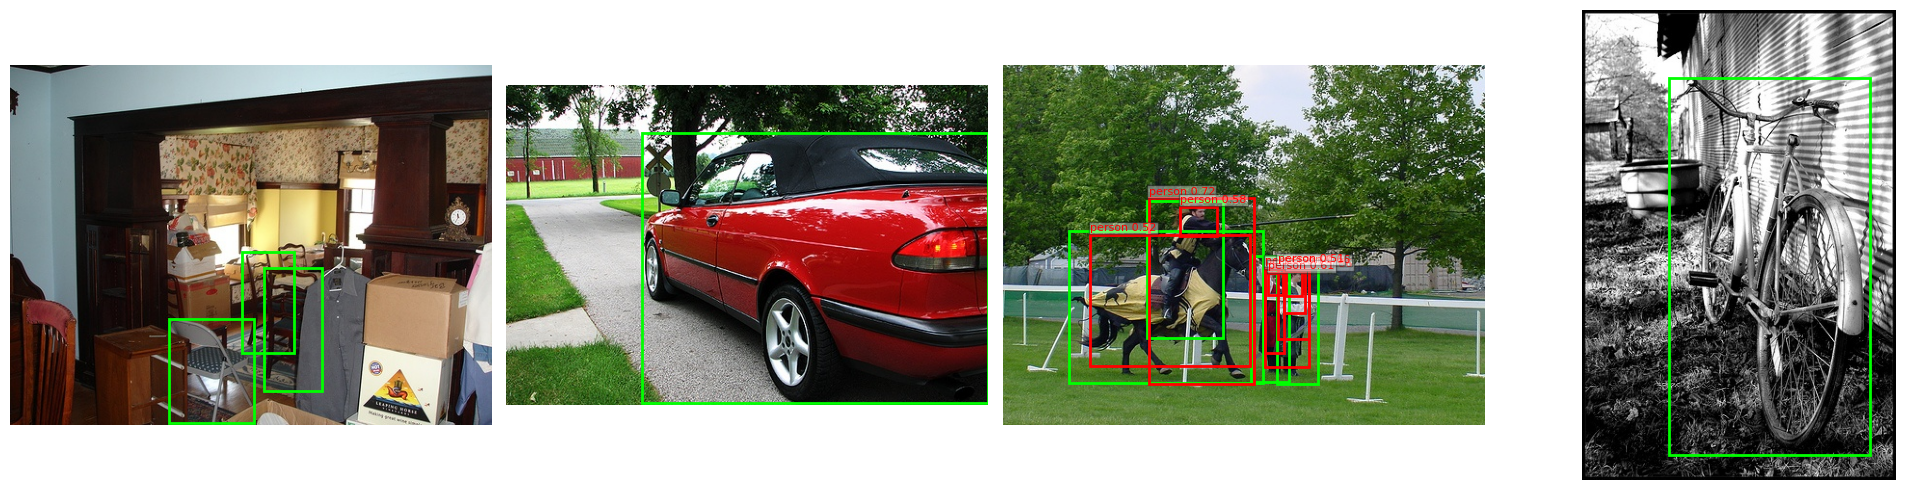

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torch.utils.data import Subset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONF_THRESH = 0.5

def get_model(weights_path):
    model = fasterrcnn_resnet50_fpn(weights=None)
    in_f = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, 21)
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def visualize(model, dataset, n=4):
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    for ax, idx in zip(axes, range(n)):
        img_tensor, target = dataset[idx]
        with torch.no_grad():
            pred = model([img_tensor.to(DEVICE)])[0]

        img_np = img_tensor.permute(1, 2, 0).numpy()
        ax.imshow(img_np)

        # Ground truth — green
        for box in target["boxes"]:
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="lime", facecolor="none"
            ))

        # Predictions — red, filtered by confidence
        keep = pred["scores"] >= CONF_THRESH
        for box, label, score in zip(
            pred["boxes"][keep].cpu(),
            pred["labels"][keep].cpu(),
            pred["scores"][keep].cpu()
        ):
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            ))
            ax.text(x1, y1 - 4,
                    f"{VOC_CLASSES[label.item()]} {score:.2f}",
                    color="red", fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.4, pad=1))

        ax.axis("off")

    plt.tight_layout()
    plt.savefig("viz_output.png", dpi=150)
    plt.show()

# --- run ---
# Pick the first checkpoint that actually exists (works on Kaggle and locally).
import os
_candidates = [
    "faster_rcnn_best.pth",
    "faster_rcnn_final.pth",
    "/kaggle/working/faster_rcnn_best.pth",
    "/kaggle/working/faster_rcnn_final.pth",
]
ckpt = next((p for p in _candidates if os.path.exists(p)), None)
if ckpt is None:
    raise FileNotFoundError(
        "No Faster R-CNN checkpoint found. Run the training cell first."
    )
print(f"Loading checkpoint: {ckpt}")

model = get_model(ckpt)
val_ds = Subset(VOCDataset(split="val"), range(100))
visualize(model, val_ds, n=4)

Loading checkpoint: faster_rcnn_best.pth


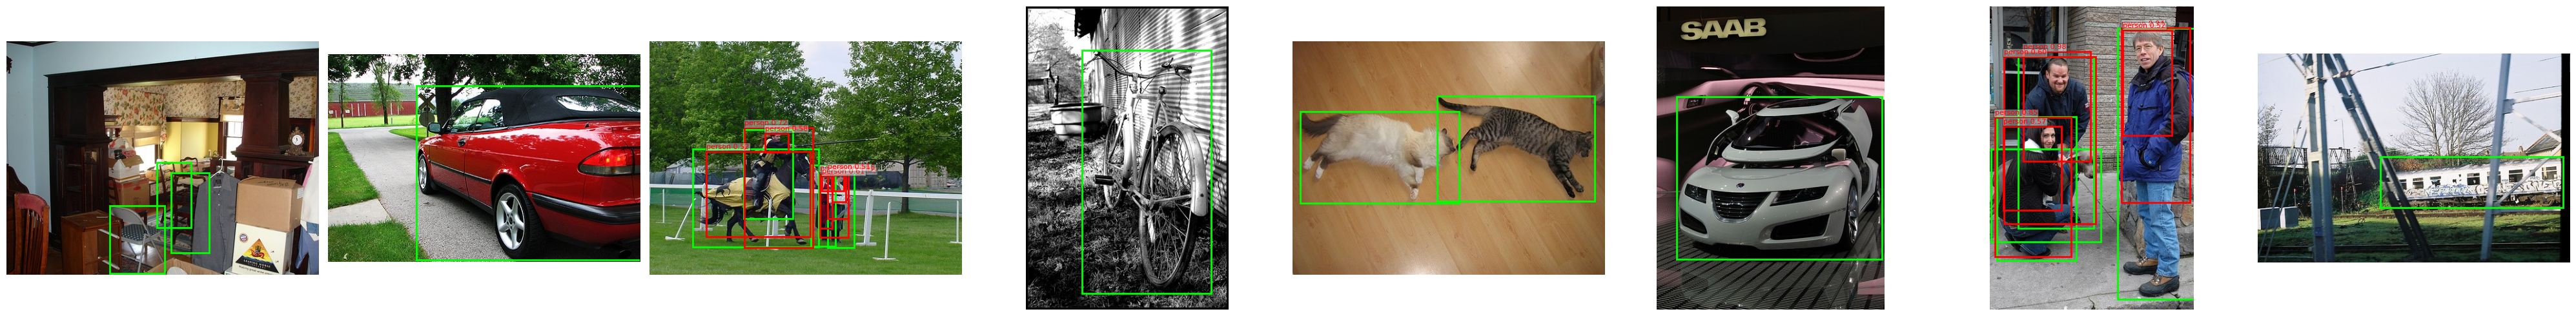

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torch.utils.data import Subset
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONF_THRESH = 0.5

def get_model(weights_path):
    model = fasterrcnn_resnet50_fpn(weights=None)
    in_f = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, 21)
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def visualize(model, dataset, n=4):
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    for ax, idx in zip(axes, range(n)):
        img_tensor, target = dataset[idx]
        with torch.no_grad():
            pred = model([img_tensor.to(DEVICE)])[0]

        img_np = img_tensor.permute(1, 2, 0).numpy()
        ax.imshow(img_np)

        # Ground truth — green
        for box in target["boxes"]:
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="lime", facecolor="none"
            ))

        # Predictions — red, filtered by confidence
        keep = pred["scores"] >= CONF_THRESH
        for box, label, score in zip(
            pred["boxes"][keep].cpu(),
            pred["labels"][keep].cpu(),
            pred["scores"][keep].cpu()
        ):
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            ))
            ax.text(x1, y1 - 4,
                    f"{VOC_CLASSES[label.item()]} {score:.2f}",
                    color="red", fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.4, pad=1))

        ax.axis("off")

    plt.tight_layout()
    plt.savefig("viz_output.png", dpi=150)
    plt.show()

# --- run ---
# Pick the first checkpoint that actually exists (works on Kaggle and locally).
import os
_candidates = [
    "faster_rcnn_best.pth",
    "faster_rcnn_final.pth",
    "/kaggle/working/faster_rcnn_best.pth",
    "/kaggle/working/faster_rcnn_final.pth",
]
ckpt = next((p for p in _candidates if os.path.exists(p)), None)
if ckpt is None:
    raise FileNotFoundError(
        "No Faster R-CNN checkpoint found. Run the training cell first."
    )
print(f"Loading checkpoint: {ckpt}")

model = get_model(ckpt)
val_ds = Subset(VOCDataset(split="val"), range(100))
visualize(model, val_ds, n=8)

**III. Segmentation**

In [18]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import os
import cv2
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Auto-detect dataset path ─────────────────────────────────────────────────
_CANDIDATE_PAIRS = [
    ("archive/PNG/Original",                                      "archive/PNG/Ground Truth"),
    ("lab4/archive/PNG/Original",                                  "lab4/archive/PNG/Ground Truth"),
    ("/kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Original",   "/kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Ground Truth"),
    ("/kaggle/input/cvc-clinicdb/PNG/Original",                    "/kaggle/input/cvc-clinicdb/PNG/Ground Truth"),
]
IMG_DIR = MASK_DIR = None
for _img, _mask in _CANDIDATE_PAIRS:
    if os.path.isdir(_img) and os.path.isdir(_mask):
        IMG_DIR, MASK_DIR = _img, _mask
        break
if IMG_DIR is None:
    raise FileNotFoundError(
        "CVC-ClinicDB not found. Place the dataset so that "
        "'<root>/PNG/Original' and '<root>/PNG/Ground Truth' exist."
    )
print(f"Image dir: {IMG_DIR}")
print(f"Mask  dir: {MASK_DIR}")

Image dir: archive/PNG/Original
Mask  dir: archive/PNG/Ground Truth


1. Dataset & Loaders

In [20]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Auto-tune for hardware so the notebook actually finishes on a CPU laptop.
if DEVICE == "cuda":
    IMG_SIZE   = 256
    BATCH_SIZE = 8
    EPOCHS     = 50
else:
    IMG_SIZE   = 128
    BATCH_SIZE = 2
    EPOCHS     = 5

class ClinicDB(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.imgs  = img_paths
        self.masks = mask_paths
        self.tf    = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img  = cv2.imread(self.imgs[i])
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks[i], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)            # binary {0,1}

        if self.tf:
            aug  = self.tf(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]

        return img, mask.unsqueeze(0)                      # (C,H,W), (1,H,W)


def get_transforms(train=True):
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


imgs  = sorted(glob(os.path.join(IMG_DIR,  "*.png")))
masks = sorted(glob(os.path.join(MASK_DIR, "*.png")))
print(f"Found {len(imgs)} images / {len(masks)} masks")
assert len(imgs) > 0 and len(imgs) == len(masks), "Dataset mismatch"

tr_i, val_i, tr_m, val_m = train_test_split(
    imgs, masks, test_size=0.2, random_state=42
)

train_ds = ClinicDB(tr_i,  tr_m,  get_transforms(True))
val_ds   = ClinicDB(val_i, val_m, get_transforms(False))

# Windows + Jupyter: num_workers=0 to avoid pickle/spawn crashes.
_nw  = 2 if DEVICE == "cuda" and os.name != "nt" else 0
_pin = DEVICE == "cuda"
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=_nw, pin_memory=_pin)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=_nw, pin_memory=_pin)

print(f"Device: {DEVICE} | img_size: {IMG_SIZE} | batch: {BATCH_SIZE} | epochs: {EPOCHS}")
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")

Found 612 images / 612 masks
Device: cpu | img_size: 128 | batch: 2 | epochs: 5
Train: 489  Val: 123


2. U-Net Model

In [21]:
class DoubleConv(nn.Module):
    """(Conv2d → BN → ReLU) × 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=(64, 128, 256, 512)):
        super().__init__()
        # Encoder
        self.enc  = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        ch = in_ch
        for f in features:
            self.enc.append(DoubleConv(ch, f))
            ch = f
        # Bottleneck
        self.bottleneck = DoubleConv(ch, ch * 2)
        ch = ch * 2
        # Decoder
        self.dec_up   = nn.ModuleList()
        self.dec_conv = nn.ModuleList()
        for f in reversed(features):
            self.dec_up.append(
                nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2)
            )
            # f*2 because of skip concat
            self.dec_conv.append(DoubleConv(f * 2, f))
            ch = f
        self.head = nn.Conv2d(ch, out_ch, 1)

    def forward(self, x):
        skips = []
        for enc in self.enc:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i, (up, conv) in enumerate(zip(self.dec_up, self.dec_conv)):
            x = up(x)
            s = skips[i]
            if x.shape != s.shape:
                # Pad on right/bottom if upsample size mismatched skip.
                x = TF.pad(x, [0, s.shape[3] - x.shape[3],
                               0, s.shape[2] - x.shape[2]])
            x = torch.cat([s, x], dim=1)
            x = conv(x)
        return self.head(x)

3. Loss & Metrics

In [22]:
class BCEDiceLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1e-6):
        super().__init__()
        self.alpha  = alpha
        self.bce    = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce  = self.bce(logits, targets)
        prob = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(2, 3))
        dice  = 1 - (2 * inter + self.smooth) / (
            prob.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + self.smooth
        )
        return self.alpha * bce + (1 - self.alpha) * dice.mean()


def dice_score(pred_logits, targets, thresh=0.5, smooth=1e-6):
    pred  = (torch.sigmoid(pred_logits) > thresh).float()
    inter = (pred * targets).sum(dim=(2, 3))
    return ((2 * inter + smooth) /
            (pred.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + smooth)).mean().item()


def iou_score(pred_logits, targets, thresh=0.5, smooth=1e-6):
    pred  = (torch.sigmoid(pred_logits) > thresh).float()
    inter = (pred * targets).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - inter
    return ((inter + smooth) / (union + smooth)).mean().item()

4. Train / Eval

In [23]:
LR = 1e-4

model     = UNet().to(DEVICE)
criterion = BCEDiceLoss(alpha=0.5)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def run_epoch(loader, train=True):
    model.train(train)
    tot_loss = tot_dice = tot_iou = 0.0
    ctx = torch.enable_grad if train else torch.no_grad
    with ctx():
        for imgs_b, masks_b in loader:
            imgs_b  = imgs_b.to(DEVICE)
            masks_b = masks_b.to(DEVICE)
            logits  = model(imgs_b)
            loss    = criterion(logits, masks_b)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            tot_loss += loss.item()
            tot_dice += dice_score(logits, masks_b)
            tot_iou  += iou_score(logits, masks_b)
    n = len(loader)
    return tot_loss / n, tot_dice / n, tot_iou / n


best_dice = 0.0
for ep in range(1, EPOCHS + 1):
    tr_loss, tr_dice, tr_iou = run_epoch(train_dl, train=True)
    vl_loss, vl_dice, vl_iou = run_epoch(val_dl,   train=False)
    scheduler.step()

    print(f"Ep {ep:3d} | "
          f"TrLoss {tr_loss:.4f}  TrDice {tr_dice:.4f}  TrIoU {tr_iou:.4f} | "
          f"VlLoss {vl_loss:.4f}  VlDice {vl_dice:.4f}  VlIoU {vl_iou:.4f}",
          flush=True)

    if vl_dice > best_dice:
        best_dice = vl_dice
        torch.save(model.state_dict(), "best_unet.pth")
        print(f"  ↑ saved (val dice {best_dice:.4f})")

Ep   1 | TrLoss 0.5898  TrDice 0.4215  TrIoU 0.3005 | VlLoss 0.5764  VlDice 0.4462  VlIoU 0.3157
  ↑ saved (val dice 0.4462)
Ep   2 | TrLoss 0.4749  TrDice 0.5507  TrIoU 0.4240 | VlLoss 0.4225  VlDice 0.6410  VlIoU 0.5162
  ↑ saved (val dice 0.6410)
Ep   3 | TrLoss 0.4063  TrDice 0.6230  TrIoU 0.4959 | VlLoss 0.3805  VlDice 0.6702  VlIoU 0.5494
  ↑ saved (val dice 0.6702)
Ep   4 | TrLoss 0.3514  TrDice 0.6981  TrIoU 0.5765 | VlLoss 0.3282  VlDice 0.7158  VlIoU 0.5924
  ↑ saved (val dice 0.7158)
Ep   5 | TrLoss 0.3229  TrDice 0.7346  TrIoU 0.6173 | VlLoss 0.3251  VlDice 0.7332  VlIoU 0.6139
  ↑ saved (val dice 0.7332)


5. Quick visual check

Loading checkpoint: best_unet.pth


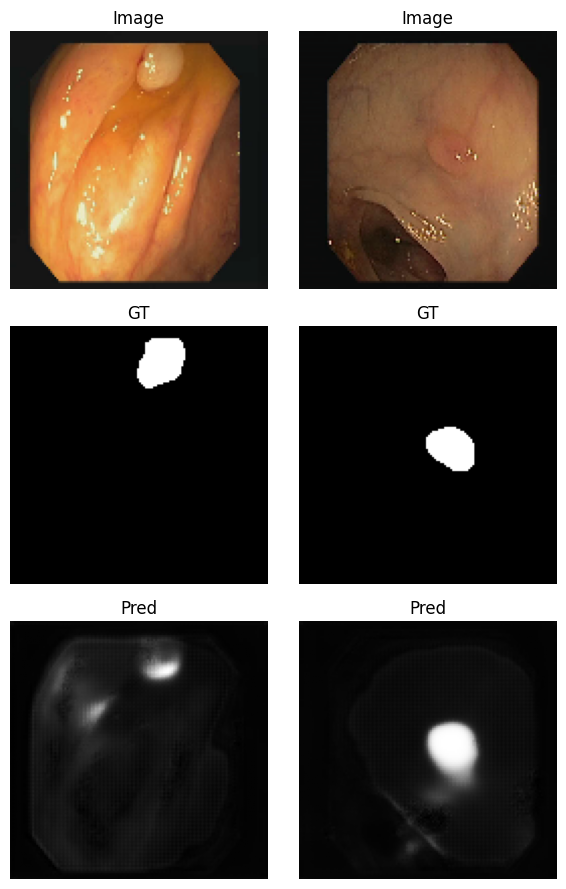

In [24]:
import matplotlib.pyplot as plt

# Pick the first checkpoint that actually exists.
_ckpt_candidates = [
    "best_unet.pth",
    "/kaggle/working/best_unet.pth",
]
_ckpt = next((p for p in _ckpt_candidates if os.path.exists(p)), None)
if _ckpt is None:
    raise FileNotFoundError("No U-Net checkpoint found. Run the training cell first.")
print(f"Loading checkpoint: {_ckpt}")
model.load_state_dict(torch.load(_ckpt, map_location=DEVICE))
model.eval()

imgs_b, masks_b = next(iter(val_dl))
with torch.no_grad():
    preds = torch.sigmoid(model(imgs_b.to(DEVICE))).cpu()

n_show = min(4, imgs_b.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))
if n_show == 1:
    axes = axes.reshape(3, 1)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for col in range(n_show):
    img_show = imgs_b[col].permute(1, 2, 0).numpy()
    img_show = np.clip(img_show * std + mean, 0, 1)

    axes[0, col].imshow(img_show);                   axes[0, col].set_title("Image")
    axes[1, col].imshow(masks_b[col, 0], cmap="gray"); axes[1, col].set_title("GT")
    axes[2, col].imshow(preds[col, 0],   cmap="gray"); axes[2, col].set_title("Pred")
    for r in range(3):
        axes[r, col].axis("off")

plt.tight_layout()
_out_dir = os.path.dirname(os.path.abspath(_ckpt))
plt.savefig(os.path.join(_out_dir, "unet_predictions.png"), dpi=150)
plt.show()